# Naive Bayes | SMS Spam Detection
**Dataset:** SMS Spam Collection (5,572 messages -- 747 spam, 4,825 ham)
**Problem:** Classify SMS messages as spam or ham (legitimate) based on the text content.


Every model in this series so far has worked on structured tabular data -- rows of numbers. Naive Bayes is the standard first approach for text classification because it is fast, works well with high-dimensional sparse data (thousands of word features), and is directly grounded in probability theory. No scaling required, no distance computation, no matrix inversion.

**The connection to your maths file:**
This notebook is Bayes theorem from your Statistics file in working code. The formula you studied:

```
P(A|B) = P(B|A) x P(A) / P(B)
```

becomes:

```
P(spam | words) = P(words | spam) x P(spam) / P(words)
```

You will compute this from scratch before using sklearn.

**Why it is called Naive:**
It assumes all words in a message are independent of each other -- that the presence of "free" does not affect the probability of seeing "money". This is obviously false in real language, but the assumption works surprisingly well in practice and makes the computation tractable.

**What this notebook covers:**
1. Text preprocessing -- cleaning, tokenizing, removing stopwords
2. Bayes theorem applied to spam detection -- manual computation
3. Bag of Words and TF-IDF -- converting text to numbers
4. Multinomial, Bernoulli, and Gaussian Naive Bayes -- when to use each
5. The class imbalance problem -- 87% ham, 13% spam
6. Threshold tuning for spam detection specifically
7. Most spam-indicating and ham-indicating words
8. Comparison with Logistic Regression on the same data


## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter

from sklearn.naive_bayes import MultinomialNB, BernoulliNB, GaussianNB, ComplementNB
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)
from sklearn.pipeline import Pipeline

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
print("Imports ready")

Imports ready


## 1. Load and Clean Data

In [2]:

df = pd.read_csv('../../Datasets/Spam/spam.csv', encoding='latin-1')

# Keep only the two useful columns, rename them
df = df[['v1', 'v2']].rename(columns={'v1': 'label', 'v2': 'message'})

# Encode label
df['label_num'] = (df['label'] == 'spam').astype(int)

print(f"Dataset shape: {df.shape}")
print()
print("Class distribution:")
counts = df['label'].value_counts()
for label, count in counts.items():
    pct = count / len(df) * 100
    print(f"  {label:<6} {count:>5} messages ({pct:.1f}%)")
print()
print("Sample messages:")
print()
for _, row in df[df['label']=='spam'].head(3).iterrows():
    print(f"  [SPAM] {row['message'][:100]}")
print()
for _, row in df[df['label']=='ham'].head(3).iterrows():
    print(f"  [HAM]  {row['message'][:100]}")

Dataset shape: (5572, 3)

Class distribution:
  ham     4825 messages (86.6%)
  spam     747 messages (13.4%)

Sample messages:

  [SPAM] Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entr
  [SPAM] FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some fun you up for it s
  [SPAM] WINNER!! As a valued network customer you have been selected to receivea å£900 prize reward! To clai

  [HAM]  Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got a
  [HAM]  Ok lar... Joking wif u oni...
  [HAM]  U dun say so early hor... U c already then say...


In [3]:
# Message length analysis
df['msg_length']    = df['message'].apply(len)
df['word_count']    = df['message'].apply(lambda x: len(x.split()))
df['num_digits']    = df['message'].apply(lambda x: sum(c.isdigit() for c in x))
df['num_uppercase'] = df['message'].apply(lambda x: sum(c.isupper() for c in x))
df['has_url']       = df['message'].apply(lambda x: int('http' in x.lower() or 'www' in x.lower()))
df['has_currency']  = df['message'].apply(lambda x: int(any(s in x for s in ['$', '£', 'free', 'Free', 'FREE'])))

print("Message statistics by class:")
stats = df.groupby('label')[['msg_length', 'word_count', 'num_digits', 'num_uppercase']].mean().round(1)
print(stats)
print()
print("Spam messages are:")
spam_len  = df[df['label']=='spam']['msg_length'].mean()
ham_len   = df[df['label']=='ham']['msg_length'].mean()
print(f"  {spam_len/ham_len:.1f}x longer on average")
print(f"  More digits (phone numbers, codes)")
print(f"  More uppercase (shouting)")

Message statistics by class:
       msg_length  word_count  num_digits  num_uppercase
label                                                   
ham          71.0        14.2         0.3            4.0
spam        138.9        23.9        15.8           15.4

Spam messages are:
  2.0x longer on average
  More digits (phone numbers, codes)
  More uppercase (shouting)


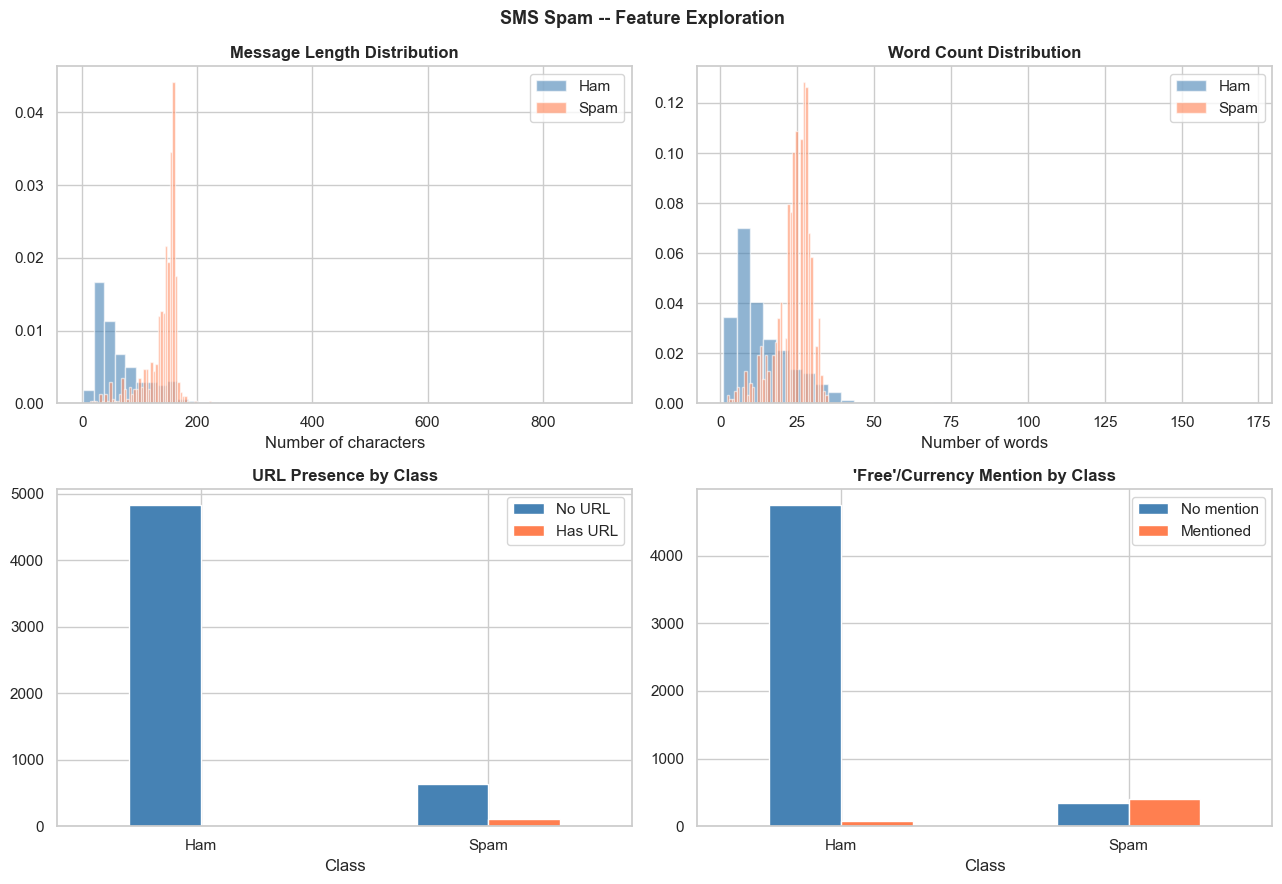

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# Message length
axes[0,0].hist(df[df['label']=='ham']['msg_length'],  bins=50, alpha=0.6,
               color='steelblue', label='Ham',  density=True)
axes[0,0].hist(df[df['label']=='spam']['msg_length'], bins=50, alpha=0.6,
               color='coral',     label='Spam', density=True)
axes[0,0].set_title('Message Length Distribution', fontweight='bold')
axes[0,0].set_xlabel('Number of characters')
axes[0,0].legend()

# Word count
axes[0,1].hist(df[df['label']=='ham']['word_count'],  bins=40, alpha=0.6,
               color='steelblue', label='Ham',  density=True)
axes[0,1].hist(df[df['label']=='spam']['word_count'], bins=40, alpha=0.6,
               color='coral',     label='Spam', density=True)
axes[0,1].set_title('Word Count Distribution', fontweight='bold')
axes[0,1].set_xlabel('Number of words')
axes[0,1].legend()

# URL presence
url_counts = df.groupby(['label', 'has_url']).size().unstack(fill_value=0)
url_counts.plot(kind='bar', ax=axes[1,0], color=['steelblue', 'coral'],
                edgecolor='white')
axes[1,0].set_title('URL Presence by Class', fontweight='bold')
axes[1,0].set_xlabel('Class')
axes[1,0].set_xticklabels(['Ham', 'Spam'], rotation=0)
axes[1,0].legend(['No URL', 'Has URL'])

# Currency/free mention
curr_counts = df.groupby(['label', 'has_currency']).size().unstack(fill_value=0)
curr_counts.plot(kind='bar', ax=axes[1,1], color=['steelblue', 'coral'],
                  edgecolor='white')
axes[1,1].set_title("'Free'/Currency Mention by Class", fontweight='bold')
axes[1,1].set_xlabel('Class')
axes[1,1].set_xticklabels(['Ham', 'Spam'], rotation=0)
axes[1,1].legend(['No mention', 'Mentioned'])

plt.suptitle('SMS Spam -- Feature Exploration', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 2. Bayes Theorem Applied to Spam -- Manual Computation

Before using sklearn, build it from scratch so you see exactly what is happening.

**The formula:**
```
P(spam | message) = P(message | spam) x P(spam) / P(message)
```

Since we compare spam vs ham, we only need the ratio:
```
P(spam | message)     P(message | spam) x P(spam)
-----------------  =  ---------------------------
P(ham  | message)     P(message | ham)  x P(ham)
```

**The naive independence assumption:**
```
P(message | spam) = P(word1 | spam) x P(word2 | spam) x ... x P(wordn | spam)
```

Each word probability is estimated from training data:
```
P(word | spam) = (count of word in spam messages + 1) / (total words in spam + vocabulary size)
```

The +1 is Laplace smoothing -- prevents zero probability for unseen words.


In [5]:
# Split first -- compute all statistics on training data only
X = df['message']
y = df['label_num']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

train_df = pd.DataFrame({'message': X_train, 'label': y_train})

# --- Step 1: Prior probabilities ---
n_spam = (train_df['label'] == 1).sum()
n_ham  = (train_df['label'] == 0).sum()
n_total = len(train_df)

p_spam = n_spam / n_total
p_ham  = n_ham  / n_total

print(f"Prior probabilities (from training data):")
print(f"  P(spam) = {n_spam}/{n_total} = {p_spam:.4f}")
print(f"  P(ham)  = {n_ham}/{n_total} = {p_ham:.4f}")

Prior probabilities (from training data):
  P(spam) = 598/4457 = 0.1342
  P(ham)  = 3859/4457 = 0.8658


In [6]:
# --- Step 2: Word frequencies per class ---
def tokenize(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    return text.split()

spam_words = []
ham_words  = []

for _, row in train_df.iterrows():
    tokens = tokenize(row['message'])
    if row['label'] == 1:
        spam_words.extend(tokens)
    else:
        ham_words.extend(tokens)

spam_counts = Counter(spam_words)
ham_counts  = Counter(ham_words)
vocabulary  = set(spam_words + ham_words)

print(f"Vocabulary size: {len(vocabulary):,} unique words")
print(f"Total spam words: {len(spam_words):,}")
print(f"Total ham words:  {len(ham_words):,}")
print()
print("Top 15 words in SPAM messages:")
for word, count in spam_counts.most_common(15):
    print(f"  {word:<15} {count:>5}")

Vocabulary size: 7,560 unique words
Total spam words: 12,678
Total ham words:  53,024

Top 15 words in SPAM messages:
  to                556
  a                 307
  call              278
  you               234
  your              214
  free              177
  for               166
  the               165
  or                148
  now               148
  is                136
  u                 123
  txt               122
  ur                118
  have              110


In [7]:
print("Top 15 words in HAM messages:")
for word, count in ham_counts.most_common(15):
    print(f"  {word:<15} {count:>5}")

Top 15 words in HAM messages:
  i                1740
  you              1482
  to               1239
  the               897
  a                 829
  u                 793
  and               697
  in                663
  is                593
  me                592
  my                586
  it                468
  of                416
  for               399
  that              383


In [8]:
# --- Step 3: Compute log probabilities (avoid underflow) ---
# Multiplying many small probabilities together causes numerical underflow
# log(a x b x c) = log(a) + log(b) + log(c) -- use addition instead

vocab_size = len(vocabulary)
total_spam_words = sum(spam_counts.values())
total_ham_words  = sum(ham_counts.values())

def log_likelihood(word, counts, total):
    # Laplace smoothing: add 1 to numerator, vocab_size to denominator
    count = counts.get(word, 0)
    return np.log((count + 1) / (total + vocab_size))

def predict_naive_bayes(message):
    tokens = tokenize(message)

    # Start with log prior
    log_prob_spam = np.log(p_spam)
    log_prob_ham  = np.log(p_ham)

    # Add log likelihood for each word
    for word in tokens:
        log_prob_spam += log_likelihood(word, spam_counts, total_spam_words)
        log_prob_ham  += log_likelihood(word, ham_counts,  total_ham_words)

    # Convert back to probability using softmax
    max_log = max(log_prob_spam, log_prob_ham)
    prob_spam = np.exp(log_prob_spam - max_log)
    prob_ham  = np.exp(log_prob_ham  - max_log)
    prob_spam_norm = prob_spam / (prob_spam + prob_ham)

    return prob_spam_norm

# Test on a few messages
test_messages = [
    "FREE entry! Win a prize! Call now! Limited time offer!",
    "Hey, are you coming to the party tonight?",
    "Congratulations! You have won 1000 pounds. Text CLAIM to 80086",
    "Can you pick up some milk on the way home?",
    "URGENT: Your account has been suspended. Click here to verify.",
]

print("Manual Naive Bayes predictions:")
print()
for msg in test_messages:
    prob = predict_naive_bayes(msg)
    label = "SPAM" if prob >= 0.5 else "HAM "
    print(f"  [{label}] P(spam)={prob:.3f}  {msg[:60]}")

Manual Naive Bayes predictions:

  [SPAM] P(spam)=1.000  FREE entry! Win a prize! Call now! Limited time offer!
  [HAM ] P(spam)=0.000  Hey, are you coming to the party tonight?
  [SPAM] P(spam)=1.000  Congratulations! You have won 1000 pounds. Text CLAIM to 800
  [HAM ] P(spam)=0.000  Can you pick up some milk on the way home?
  [SPAM] P(spam)=1.000  URGENT: Your account has been suspended. Click here to verif


In [9]:
# Evaluate manual implementation on test set
manual_probs = [predict_naive_bayes(msg) for msg in X_test]
manual_preds = [1 if p >= 0.5 else 0 for p in manual_probs]

print("Manual Naive Bayes on test set:")
print(f"  Accuracy:  {accuracy_score(y_test, manual_preds):.4f}")
print(f"  Precision: {precision_score(y_test, manual_preds):.4f}")
print(f"  Recall:    {recall_score(y_test, manual_preds):.4f}")
print(f"  F1 Score:  {f1_score(y_test, manual_preds):.4f}")
print()
print("This is the same computation sklearn does internally.")
print("The sklearn version adds optimizations but the math is identical.")

Manual Naive Bayes on test set:
  Accuracy:  0.9695
  Precision: 0.8528
  Recall:    0.9329
  F1 Score:  0.8910

This is the same computation sklearn does internally.
The sklearn version adds optimizations but the math is identical.


## 3. Text Preprocessing Pipeline

In [10]:
import string

# Standard NLP preprocessing steps
stopwords_basic = set([
    'i', 'me', 'my', 'we', 'our', 'you', 'your', 'he', 'she', 'it',
    'they', 'what', 'which', 'who', 'this', 'that', 'these', 'those',
    'am', 'is', 'are', 'was', 'were', 'be', 'been', 'being',
    'have', 'has', 'had', 'do', 'does', 'did', 'will', 'would',
    'could', 'should', 'may', 'might', 'shall', 'can',
    'a', 'an', 'the', 'and', 'but', 'if', 'or', 'as', 'of',
    'at', 'by', 'for', 'with', 'about', 'into', 'through', 'to',
    'in', 'on', 'is', 'not', 'no', 'so', 'up', 'out', 'just'
])

def preprocess(text):
    # Lowercase
    text = text.lower()
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # Remove digits
    text = re.sub(r'\d+', '', text)
    # Tokenize
    tokens = text.split()
    # Remove stopwords and short tokens
    tokens = [t for t in tokens if t not in stopwords_basic and len(t) > 2]
    return ' '.join(tokens)

df['cleaned'] = df['message'].apply(preprocess)

print("Preprocessing examples:")
print()
for _, row in df[df['label_num']==1].head(3).iterrows():
    print(f"  Original: {row['message'][:80]}")
    print(f"  Cleaned:  {row['cleaned'][:80]}")
    print()

Preprocessing examples:

  Original: Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 8
  Cleaned:  free entry wkly comp win cup final tkts text receive entry questionstd txt ratet

  Original: FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some
  Cleaned:  freemsg hey there darling its weeks now word back like some fun still xxx std ch

  Original: WINNER!! As a valued network customer you have been selected to receivea å£900 p
  Cleaned:  winner valued network customer selected receivea prize reward claim call claim c



## 4. Bag of Words and TF-IDF

In [11]:
# Bag of Words: count how many times each word appears in each message
# Result: a matrix of (n_messages x vocabulary_size) -- usually very sparse

X_clean = df['cleaned']
y_all   = df['label_num']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clean, y_all, test_size=0.2, random_state=42, stratify=y_all
)

# CountVectorizer -- Bag of Words
bow = CountVectorizer(max_features=5000)
X_train_bow = bow.fit_transform(X_train_c)
X_test_bow  = bow.transform(X_test_c)

print("Bag of Words matrix:")
print(f"  Shape: {X_train_bow.shape}")
print(f"  (rows=messages, cols=unique words in vocabulary)")
print(f"  Non-zero entries: {X_train_bow.nnz:,}  ({X_train_bow.nnz / X_train_bow.shape[0] / X_train_bow.shape[1] * 100:.2f}% dense)")
print()
print("The matrix is very sparse -- most messages contain only a tiny fraction")
print("of all possible words. Most entries are zero.")

Bag of Words matrix:
  Shape: (4457, 5000)
  (rows=messages, cols=unique words in vocabulary)
  Non-zero entries: 35,132  (0.16% dense)

The matrix is very sparse -- most messages contain only a tiny fraction
of all possible words. Most entries are zero.


In [12]:
# TF-IDF: Term Frequency x Inverse Document Frequency
# TF  = how often a word appears in THIS message
# IDF = log(total messages / messages containing this word)
# Words that appear in every message (low IDF) are downweighted
# Words that are rare but appear in this message (high IDF) are upweighted

tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train_c)
X_test_tfidf  = tfidf.transform(X_test_c)

print("TF-IDF vs Bag of Words:")
print()
print("  Bag of Words: raw count of each word")
print("  TF-IDF: weighted count that penalizes common words")
print()
print("Example -- the word 'the' appears in almost every message.")
print("  Bag of Words: count = 3 (just counts occurrences)")
print("  TF-IDF: score very low (common word, low IDF weight)")
print()
print("Example -- the word 'prize' appears mainly in spam.")
print("  Bag of Words: count = 1")
print("  TF-IDF: score higher (rare word, high IDF weight)")

# Show IDF values for key words
feature_names = tfidf.get_feature_names_out()
idf_values = tfidf.idf_

idf_df = pd.DataFrame({'word': feature_names, 'idf': idf_values})
print()
print("IDF values for selected words (higher = rarer across messages):")
key_words = ['free', 'prize', 'win', 'call', 'txt', 'urgent',
             'love', 'time', 'good', 'know']
for word in key_words:
    if word in idf_df['word'].values:
        val = idf_df[idf_df['word']==word]['idf'].values[0]
        print(f"  {word:<12} IDF={val:.3f}")

TF-IDF vs Bag of Words:

  Bag of Words: raw count of each word
  TF-IDF: weighted count that penalizes common words

Example -- the word 'the' appears in almost every message.
  Bag of Words: count = 3 (just counts occurrences)
  TF-IDF: score very low (common word, low IDF weight)

Example -- the word 'prize' appears mainly in spam.
  Bag of Words: count = 1
  TF-IDF: score higher (rare word, high IDF weight)

IDF values for selected words (higher = rarer across messages):
  free         IDF=4.198
  prize        IDF=5.292
  win          IDF=5.325
  call         IDF=3.323
  txt          IDF=4.590
  urgent       IDF=5.432
  love         IDF=4.535
  time         IDF=4.321
  good         IDF=4.255
  know         IDF=4.119


## 5. Naive Bayes Variants -- Which to Use When

In [13]:
# Multinomial NB: designed for count data (word counts) -- best for text
# Bernoulli NB: binary features (word present or absent) -- shorter texts
# Complement NB: better for imbalanced classes -- often beats Multinomial on spam

variants = {
    'MultinomialNB (BoW)':  (MultinomialNB(), X_train_bow, X_test_bow),
    'BernoulliNB (BoW)':    (BernoulliNB(),   X_train_bow, X_test_bow),
    'ComplementNB (BoW)':   (ComplementNB(),  X_train_bow, X_test_bow),
    'MultinomialNB (TFIDF)':(MultinomialNB(), X_train_tfidf, X_test_tfidf),
    'ComplementNB (TFIDF)': (ComplementNB(),  X_train_tfidf, X_test_tfidf),
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f"{'Model':<28} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>8} {'AUC':>8}")
print("-" * 78)

best_results = {}
for name, (model, X_tr, X_te) in variants.items():
    model.fit(X_tr, y_train_c)
    pred = model.predict(X_te)
    prob = model.predict_proba(X_te)[:,1]
    best_results[name] = {
        'accuracy':  accuracy_score(y_test_c, pred),
        'precision': precision_score(y_test_c, pred),
        'recall':    recall_score(y_test_c, pred),
        'f1':        f1_score(y_test_c, pred),
        'auc':       roc_auc_score(y_test_c, prob),
        'model': model, 'X_test': X_te, 'prob': prob, 'pred': pred
    }
    r = best_results[name]
    print(f"{name:<28} {r['accuracy']:>10.4f} {r['precision']:>10.4f} "
          f"{r['recall']:>10.4f} {r['f1']:>8.4f} {r['auc']:>8.4f}")

print()
print("MultinomialNB: designed for discrete counts, natural fit for word frequencies")
print("BernoulliNB:   treats each word as binary (present/absent), good for short texts")
print("ComplementNB:  trains on complement of each class, handles imbalance better")

Model                          Accuracy  Precision     Recall       F1      AUC
------------------------------------------------------------------------------
MultinomialNB (BoW)              0.9758     0.9357     0.8792   0.9066   0.9805
BernoulliNB (BoW)                0.9758     0.9919     0.8255   0.9011   0.9901
ComplementNB (BoW)               0.9498     0.7541     0.9262   0.8313   0.9805
MultinomialNB (TFIDF)            0.9632     0.9821     0.7383   0.8429   0.9818
ComplementNB (TFIDF)             0.9489     0.7556     0.9128   0.8267   0.9818

MultinomialNB: designed for discrete counts, natural fit for word frequencies
BernoulliNB:   treats each word as binary (present/absent), good for short texts
ComplementNB:  trains on complement of each class, handles imbalance better


## 6. Class Imbalance -- The Precision-Recall Tradeoff for Spam

In [14]:
print("Class distribution:")
print(f"  Ham:  {(y_all==0).sum()} messages ({(y_all==0).mean():.1%})")
print(f"  Spam: {(y_all==1).sum()} messages ({(y_all==1).mean():.1%})")
print()
print("With 87% ham, a model that always predicts ham achieves 87% accuracy.")
print("For a spam filter, the cost of errors is asymmetric:")
print()
print("  False Negative (spam classified as ham):")
print("    User receives spam -- annoying but manageable")
print()
print("  False Positive (ham classified as spam):")
print("    User misses a legitimate message -- potentially serious")
print()
print("For this reason, spam filters usually prioritize HIGH PRECISION:")
print("when the model says spam, it should almost always be right.")
print("Some spam getting through is tolerable. Blocking real emails is not.")

Class distribution:
  Ham:  4825 messages (86.6%)
  Spam: 747 messages (13.4%)

With 87% ham, a model that always predicts ham achieves 87% accuracy.
For a spam filter, the cost of errors is asymmetric:

  False Negative (spam classified as ham):
    User receives spam -- annoying but manageable

  False Positive (ham classified as spam):
    User misses a legitimate message -- potentially serious

For this reason, spam filters usually prioritize HIGH PRECISION:
when the model says spam, it should almost always be right.
Some spam getting through is tolerable. Blocking real emails is not.


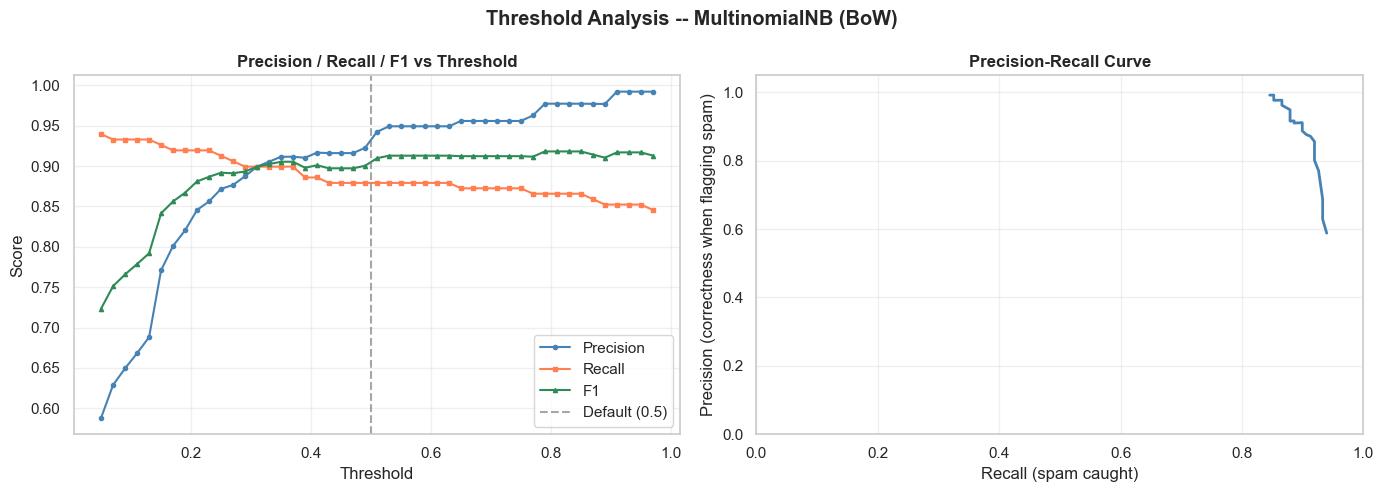

Threshold for 99%+ precision: 0.91
  Precision: 0.9922
  Recall:    0.8523
  (catching 85.2% of spam with almost no false positives)


In [15]:
# Use best model for threshold analysis
best_name = max(best_results, key=lambda k: best_results[k]['f1'])
best_res  = best_results[best_name]
y_prob_best = best_res['prob']

thresholds = np.arange(0.05, 0.99, 0.02)
precisions, recalls, f1s = [], [], []

for t in thresholds:
    preds = (y_prob_best >= t).astype(int)
    precisions.append(precision_score(y_test_c, preds, zero_division=0))
    recalls.append(recall_score(y_test_c, preds, zero_division=0))
    f1s.append(f1_score(y_test_c, preds, zero_division=0))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(thresholds, precisions, 'o-', color='steelblue', ms=3, label='Precision')
axes[0].plot(thresholds, recalls,    's-', color='coral',     ms=3, label='Recall')
axes[0].plot(thresholds, f1s,        '^-', color='seagreen',  ms=3, label='F1')
axes[0].axvline(0.5, color='gray', linestyle='--', alpha=0.7, label='Default (0.5)')
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('Score')
axes[0].set_title('Precision / Recall / F1 vs Threshold', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Precision-Recall curve
axes[1].plot(recalls, precisions, color='steelblue', linewidth=2)
axes[1].set_xlabel('Recall (spam caught)')
axes[1].set_ylabel('Precision (correctness when flagging spam)')
axes[1].set_title('Precision-Recall Curve', fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1.05])

plt.suptitle(f'Threshold Analysis -- {best_name}', fontweight='bold')
plt.tight_layout()
plt.show()

# Find threshold for high precision
high_prec_threshold = thresholds[next(i for i, p in enumerate(precisions) if p >= 0.99)]
preds_hp = (y_prob_best >= high_prec_threshold).astype(int)
print(f"Threshold for 99%+ precision: {high_prec_threshold:.2f}")
print(f"  Precision: {precision_score(y_test_c, preds_hp):.4f}")
print(f"  Recall:    {recall_score(y_test_c, preds_hp):.4f}")
print(f"  (catching {recall_score(y_test_c, preds_hp):.1%} of spam with almost no false positives)")

## 7. Most Spam and Ham Indicating Words

In [16]:
# Train MultinomialNB on full training set
mnb = MultinomialNB()
mnb.fit(X_train_bow, y_train_c)

feature_names = np.array(bow.get_feature_names_out())

# Log probability of each word given spam vs ham
log_prob_spam = mnb.feature_log_prob_[1]  # class 1 = spam
log_prob_ham  = mnb.feature_log_prob_[0]  # class 0 = ham

# Difference = how much more likely a word is in spam vs ham
spam_indicator = log_prob_spam - log_prob_ham

top_spam_idx = np.argsort(spam_indicator)[-20:][::-1]
top_ham_idx  = np.argsort(spam_indicator)[:20]

fig, axes = plt.subplots(1, 2, figsize=(15, 7))

axes[0].barh(feature_names[top_spam_idx],
             spam_indicator[top_spam_idx],
             color='coral', edgecolor='white')
axes[0].set_title('Top 20 Spam-Indicating Words
(much more common in spam than ham)',
                   fontweight='bold')
axes[0].set_xlabel('log P(word|spam) - log P(word|ham)')
axes[0].invert_yaxis()

axes[1].barh(feature_names[top_ham_idx],
             np.abs(spam_indicator[top_ham_idx]),
             color='steelblue', edgecolor='white')
axes[1].set_title('Top 20 Ham-Indicating Words
(much more common in ham than spam)',
                   fontweight='bold')
axes[1].set_xlabel('|log P(word|ham) - log P(word|spam)|')
axes[1].invert_yaxis()

plt.suptitle('What the Model Learned -- Words that Distinguish Spam from Ham',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("Spam words: promotional language, urgency, money, prizes")
print("Ham words:  conversational language, names, everyday activities")

SyntaxError: unterminated string literal (detected at line 22) (2188149204.py, line 22)

## 8. Confusion Matrix and ROC Curve

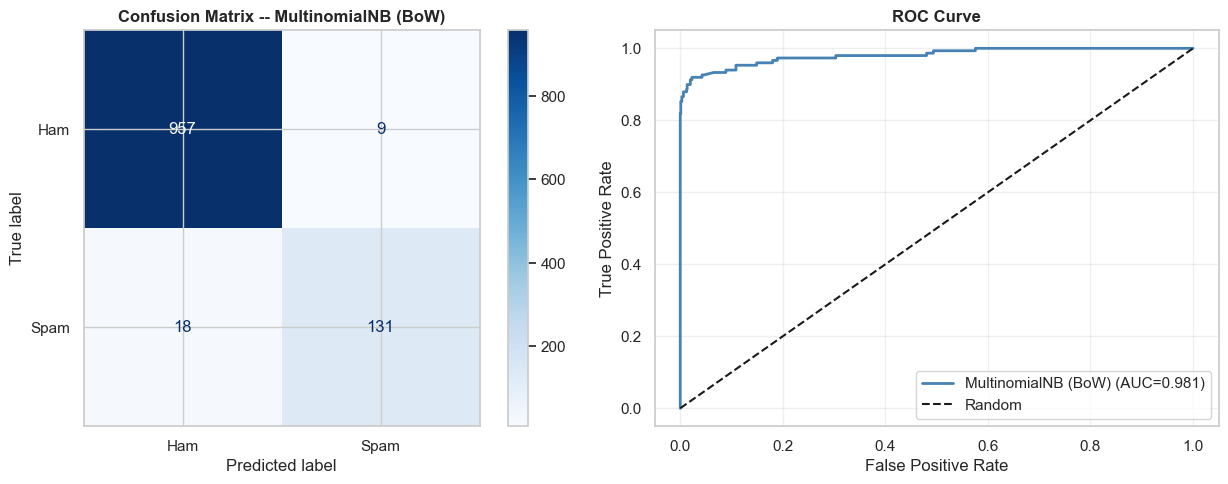

              precision    recall  f1-score   support

         Ham       0.98      0.99      0.99       966
        Spam       0.94      0.88      0.91       149

    accuracy                           0.98      1115
   macro avg       0.96      0.93      0.95      1115
weighted avg       0.98      0.98      0.98      1115



In [17]:
best_model_obj = best_res['model']
y_pred_final   = best_res['pred']
y_prob_final   = best_res['prob']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test_c, y_pred_final,
    display_labels=['Ham', 'Spam'],
    cmap='Blues', ax=axes[0]
)
axes[0].set_title(f'Confusion Matrix -- {best_name}', fontweight='bold')

fpr, tpr, _ = roc_curve(y_test_c, y_prob_final)
auc = roc_auc_score(y_test_c, y_prob_final)
axes[1].plot(fpr, tpr, color='steelblue', linewidth=2,
             label=f'{best_name} (AUC={auc:.3f})')
axes[1].plot([0,1],[0,1],'k--', label='Random')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(classification_report(y_test_c, y_pred_final, target_names=['Ham', 'Spam']))

## 9. Cross-Validation

In [18]:
# Use Pipeline for proper CV (vectorizer must be fit inside each fold)
pipe_mnb = Pipeline([
    ('vectorizer', CountVectorizer(max_features=5000)),
    ('model', MultinomialNB())
])

pipe_cnb = Pipeline([
    ('vectorizer', TfidfVectorizer(max_features=5000)),
    ('model', ComplementNB())
])

for name, pipe in [('MultinomialNB + BoW', pipe_mnb),
                    ('ComplementNB + TF-IDF', pipe_cnb)]:
    scores = {
        'accuracy':  cross_val_score(pipe, X_clean, y_all, cv=skf, scoring='accuracy'),
        'f1':        cross_val_score(pipe, X_clean, y_all, cv=skf, scoring='f1'),
        'roc_auc':   cross_val_score(pipe, X_clean, y_all, cv=skf, scoring='roc_auc'),
    }
    print(f"{name}:")
    for metric, s in scores.items():
        print(f"  {metric:<12} mean={s.mean():.4f}  std={s.std():.4f}")
    print()

MultinomialNB + BoW:
  accuracy     mean=0.9788  std=0.0051
  f1           mean=0.9196  std=0.0206
  roc_auc      mean=0.9786  std=0.0112

ComplementNB + TF-IDF:
  accuracy     mean=0.9569  std=0.0027
  f1           mean=0.8507  std=0.0113
  roc_auc      mean=0.9809  std=0.0092



## 10. Naive Bayes vs Logistic Regression

In [19]:
pipe_nb = Pipeline([
    ('vectorizer', TfidfVectorizer(max_features=5000)),
    ('model', ComplementNB())
])

pipe_lr = Pipeline([
    ('vectorizer', TfidfVectorizer(max_features=5000)),
    ('model', LogisticRegression(random_state=42, max_iter=1000))
])

pipe_nb.fit(X_train_c, y_train_c)
pipe_lr.fit(X_train_c, y_train_c)

nb_pred = pipe_nb.predict(X_test_c)
lr_pred = pipe_lr.predict(X_test_c)
nb_prob = pipe_nb.predict_proba(X_test_c)[:,1]
lr_prob = pipe_lr.predict_proba(X_test_c)[:,1]

results = {
    'Naive Bayes (ComplementNB)':  {'pred': nb_pred, 'prob': nb_prob},
    'Logistic Regression':          {'pred': lr_pred, 'prob': lr_prob},
}

print("=" * 62)
print("  Naive Bayes vs Logistic Regression -- SMS Spam")
print("=" * 62)
print(f"{'Metric':<14}", end="")
for name in results:
    print(f"  {name:>27}", end="")
print()
print("-" * 62)

for metric in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']:
    vals = []
    for res in results.values():
        if metric == 'roc_auc':
            vals.append(roc_auc_score(y_test_c, res['prob']))
        elif metric == 'accuracy':
            vals.append(accuracy_score(y_test_c, res['pred']))
        elif metric == 'precision':
            vals.append(precision_score(y_test_c, res['pred']))
        elif metric == 'recall':
            vals.append(recall_score(y_test_c, res['pred']))
        elif metric == 'f1':
            vals.append(f1_score(y_test_c, res['pred']))

    best = max(vals)
    print(f"{metric:<14}", end="")
    for val in vals:
        flag = " *" if val == best else "  "
        print(f"  {val:>26.4f}{flag}", end="")
    print()

print()
print("* = better score")
print()
print("Training time comparison:")
import time
for name, pipe in [('Naive Bayes', pipe_nb), ('Logistic Regression', pipe_lr)]:
    start = time.time()
    for _ in range(10):
        pipe.fit(X_train_c, y_train_c)
    elapsed = (time.time() - start) / 10 * 1000
    print(f"  {name:<25} {elapsed:.1f} ms per fit")

  Naive Bayes vs Logistic Regression -- SMS Spam
Metric           Naive Bayes (ComplementNB)          Logistic Regression
--------------------------------------------------------------
accuracy                            0.9489                        0.9659 *
precision                           0.7556                        0.9744 *
recall                              0.9128 *                      0.7651  
f1                                  0.8267                        0.8571 *
roc_auc                             0.9818                        0.9846 *

* = better score

Training time comparison:
  Naive Bayes               248.1 ms per fit
  Logistic Regression       397.0 ms per fit


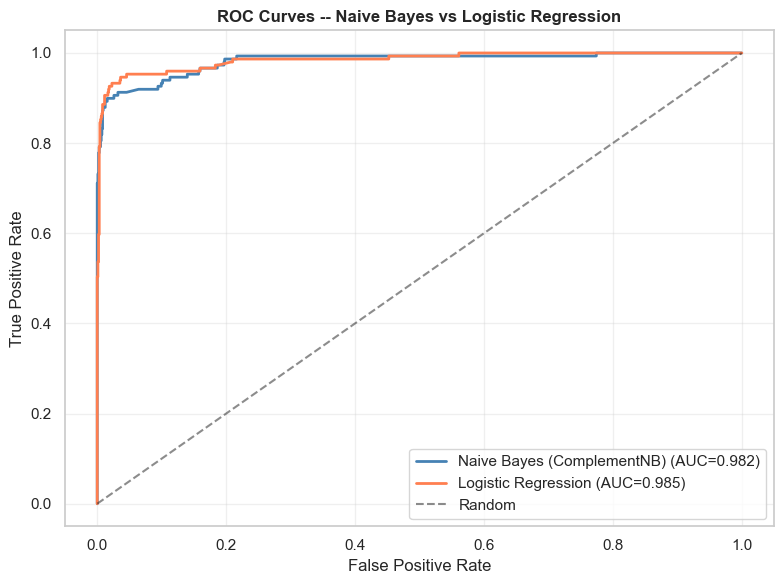

In [20]:
# ROC curves overlaid
plt.figure(figsize=(8, 6))
colors = ['steelblue', 'coral']
for (name, res), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test_c, res['prob'])
    auc = roc_auc_score(y_test_c, res['prob'])
    plt.plot(fpr, tpr, color=color, linewidth=2,
             label=f'{name} (AUC={auc:.3f})')

plt.plot([0,1],[0,1],'k--', alpha=0.5, label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves -- Naive Bayes vs Logistic Regression', fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 11. Test on Custom Messages

In [21]:
# Use the best pipeline for predictions on new messages
custom_messages = [
    "Congratulations! You have been selected to win a FREE iPhone. Reply now!",
    "Hey, what time are we meeting tomorrow?",
    "URGENT: Your bank account has been compromised. Verify at www.secure-bank.com",
    "Can you send me the notes from today's class?",
    "Win 500 pounds! Text WIN to 80085 now. Limited time only!",
    "I will be a bit late, stuck in traffic. See you soon.",
    "You have been pre-approved for a loan. Call 0800-FREE now!",
    "Happy birthday! Hope you have a wonderful day.",
]

print("Predictions on custom messages:")
print()
probs = pipe_nb.predict_proba(custom_messages)[:,1]
preds = pipe_nb.predict(custom_messages)

for msg, prob, pred in zip(custom_messages, probs, preds):
    label = "SPAM" if pred == 1 else "HAM "
    bar = '#' * int(prob * 30)
    print(f"  [{label}] P(spam)={prob:.3f}  {bar}")
    print(f"         {msg[:80]}")
    print()

Predictions on custom messages:

  [SPAM] P(spam)=0.965  ############################
         Congratulations! You have been selected to win a FREE iPhone. Reply now!

  [HAM ] P(spam)=0.049  #
         Hey, what time are we meeting tomorrow?

  [SPAM] P(spam)=0.826  ########################
         URGENT: Your bank account has been compromised. Verify at www.secure-bank.com

  [HAM ] P(spam)=0.262  #######
         Can you send me the notes from today's class?

  [SPAM] P(spam)=0.880  ##########################
         Win 500 pounds! Text WIN to 80085 now. Limited time only!

  [HAM ] P(spam)=0.140  ####
         I will be a bit late, stuck in traffic. See you soon.

  [SPAM] P(spam)=0.724  #####################
         You have been pre-approved for a loan. Call 0800-FREE now!

  [HAM ] P(spam)=0.069  ##
         Happy birthday! Hope you have a wonderful day.



## Summary

**What Naive Bayes does:**
Applies Bayes theorem with the naive independence assumption. For each class, it estimates the probability of each word appearing, then multiplies those probabilities together to score a new message. The class with the higher score wins.

**Why it works despite the naive assumption:**
Even though words are not independent (free and money often appear together in spam), the relative ordering of class probabilities is usually correct even when the absolute probabilities are wrong. Naive Bayes is often right about which class is more likely even when its probability estimates are off.

**Strengths:**
- Extremely fast to train and predict -- just counting words
- Works well on small training sets -- does not need thousands of examples
- Handles high-dimensional sparse data naturally -- 5,000 word features is fine
- No feature scaling required
- Incrementally updatable -- can add new training examples without retraining from scratch
- Directly interpretable -- you can read which words drive each prediction

**Weaknesses:**
- The independence assumption is violated in almost all real text
- Poor probability calibration -- the raw probabilities are often extreme (near 0 or 1)
- Cannot learn word order or phrase-level patterns (free money is not the same as money free)
- Struggles when features are strongly correlated

**When to use Naive Bayes:**
- Text classification as a fast baseline before trying heavier models
- Very small datasets where complex models overfit
- Real-time systems where prediction latency matters
- Email spam, sentiment analysis, document categorization

